In [49]:
# notebooks/05_baseline_model.ipynb

import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pitch_analysis import load_clean_data

# Load clean data
data = load_clean_data()
print(f"Modeling dataset: {len(data)} pitches")
print(f"Pitch types: {sorted(data['pitch_type'].unique())}")

Modeling dataset: 72098 pitches
Pitch types: ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']


# Add Pitcher Identity as Feature

In [50]:
from sklearn.preprocessing import LabelEncoder

# Encode pitcher name as a numeric feature
# This allows the model to learn pitcher specific tendencies
pitcher_encoder = LabelEncoder()
data['pitcher_encoded'] = pitcher_encoder.fit_transform(data['pitcher_name'])

# Save encoder for later use
joblib.dump(pitcher_encoder, '../models/pitcher_encoder.pkl')

print("=== Pitcher Encoding ===")
for name, code in zip(pitcher_encoder.classes_, 
                       range(len(pitcher_encoder.classes_))):
    print(f"{name}: {code}")

=== Pitcher Encoding ===
Chris Sale: 0
Corbin Burnes: 1
Dylan Cease: 2
Framber Valdez: 3
Gerrit Cole: 4
Justin Verlander: 5
Kyle Hendricks: 6
Logan Webb: 7
Marcus Stroman: 8
Max Scherzer: 9
Nestor Cortes: 10
Spencer Strider: 11
Yusei Kikuchi: 12
Zack Wheeler: 13


# Define Feature Matrix

In [51]:
# Features that describe the game situation
# These are what the model uses to recommend a pitch
feature_cols = [
    # Count state
    'balls',
    'strikes',
    
    # Game situation
    'inning',
    'score_diff',
    
    # Baserunners — individual and combined
    'on_1b',
    'on_2b', 
    'on_3b',
    'runners_on',        # total runners on base
    'scoring_position',  # runner on 2b or 3b
    
    # Matchup
    'stand_encoded',     # batter handedness
    
    # Pitcher identity — critical addition
    'pitcher_encoded',
    
    # Count state as pressure indicator
    'count_leverage',    # how much does this count matter
]

# Engineer the new features
data['stand_encoded'] = (data['stand'] == 'R').astype(int)
data['runners_on'] = (data['on_1b'].fillna(0) + 
                      data['on_2b'].fillna(0) + 
                      data['on_3b'].fillna(0))
data['scoring_position'] = (
    (data['on_2b'].fillna(0) + data['on_3b'].fillna(0)) > 0
).astype(int)

# Count leverage — two strike and three ball counts are higher leverage
data['count_leverage'] = (
    (data['strikes'] == 2).astype(int) * 2 +
    (data['balls'] == 3).astype(int) * 2 +
    (data['strikes'] == 1).astype(int) +
    (data['balls'] == 2).astype(int)
)

print("=== Engineered Features Preview ===")
print(data[feature_cols].describe())

# Encode batter handedness
data['stand_encoded'] = (data['stand'] == 'R').astype(int)

# Define target — what pitch was thrown
target_col = 'pitch_type'

print(f"\n=== Feature Matrix Preview ===")
print(data[feature_cols].describe())
print(f"\nTarget classes: {sorted(data[target_col].unique())}")

=== Engineered Features Preview ===
              balls       strikes        inning    score_diff          on_1b  \
count  72098.000000  72098.000000  72098.000000  72098.000000   72098.000000   
mean       0.857902      0.916184      3.513801     -0.155996  175104.164790   
std        0.956589      0.829757      1.861111      2.346825  285597.846645   
min        0.000000      0.000000      1.000000    -13.000000       0.000000   
25%        0.000000      0.000000      2.000000     -1.000000       0.000000   
50%        1.000000      1.000000      3.000000      0.000000       0.000000   
75%        1.000000      2.000000      5.000000      1.000000  543807.000000   
max        3.000000      2.000000     10.000000     11.000000  808982.000000   

               on_2b          on_3b    runners_on  scoring_position  \
count   72098.000000   72098.000000  7.209800e+04      72098.000000   
mean    97448.148423   48381.116411  3.209334e+05          0.198508   
std    230963.312453  169607.1

# Address Class Imbalance

In [52]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights to balance class representation
# This tells the model to pay more attention to rare pitch types
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

print("=== Class Weight Distribution ===")
unique_classes = le.inverse_transform(sorted(set(y_train)))
for cls in unique_classes:
    cls_encoded = le.transform([cls])[0]
    mask = y_train == cls_encoded
    weight = sample_weights[mask][0]
    count = mask.sum()
    print(f"{cls}: {count} samples, weight={weight:.3f}")

=== Class Weight Distribution ===
CH: 6859 samples, weight=0.934
CU: 5503 samples, weight=1.165
FC: 5649 samples, weight=1.134
FF: 19028 samples, weight=0.337
FS: 1446 samples, weight=4.432
KC: 1153 samples, weight=5.558
SI: 6998 samples, weight=0.916
SL: 8432 samples, weight=0.760
ST: 2610 samples, weight=2.455


# Train Baseline Model

In [53]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import numpy as np

# Prepare features and target
X = data[feature_cols].fillna(0)
le = LabelEncoder()
y = le.fit_transform(data['pitch_type'])

# Stratified split — preserves pitch type distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Verify stratification
print("\n=== Class Distribution in Test Set ===")
test_dist = pd.Series(le.inverse_transform(y_test)).value_counts()
print(test_dist)

# Compute class weights with cap to prevent overcorrection
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Cap weights between 0.5 and 3.0
# Lower cap from 3.0 to 2.0 to reduce KC and FS overcorrection
class_weights = np.clip(class_weights, 0.5, 2.0)
sample_weights = class_weights[y_train]

print("\n=== Adjusted Class Weights ===")
for cls, weight in zip(le.classes_, class_weights):
    count = (y_train == le.transform([cls])[0]).sum()
    print(f"{cls}: count={count}, weight={weight:.3f}")

# Train XGBoost classifier with expanded features and tuned weights
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights
)

y_pred = model.predict(X_test)

print(f"\nBaseline Model Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=le.classes_))

Training samples: 57678
Testing samples: 14420

=== Class Distribution in Test Set ===
FF    4757
SL    2108
SI    1750
CH    1715
FC    1413
CU    1376
ST     652
FS     361
KC     288
Name: count, dtype: int64

=== Adjusted Class Weights ===
CH: count=6859, weight=0.934
CU: count=5503, weight=1.165
FC: count=5649, weight=1.134
FF: count=19028, weight=0.500
FS: count=1446, weight=2.000
KC: count=1153, weight=2.000
SI: count=6998, weight=0.916
SL: count=8432, weight=0.760
ST: count=2610, weight=2.000

Baseline Model Accuracy: 0.426
Balanced Accuracy: 0.481

Classification Report:
              precision    recall  f1-score   support

          CH       0.47      0.29      0.36      1715
          CU       0.30      0.29      0.29      1376
          FC       0.44      0.60      0.51      1413
          FF       0.57      0.35      0.44      4757
          FS       0.30      0.77      0.44       361
          KC       0.17      0.52      0.25       288
          SI       0.53      0.51 

# Feature Importance

=== Feature Importance ===
             feature  importance
10   pitcher_encoded    0.578029
9      stand_encoded    0.142116
1            strikes    0.053841
0              balls    0.038285
11    count_leverage    0.030034
8   scoring_position    0.025181
2             inning    0.024361
7         runners_on    0.022932
4              on_1b    0.022192
3         score_diff    0.021190
6              on_3b    0.020998
5              on_2b    0.020842


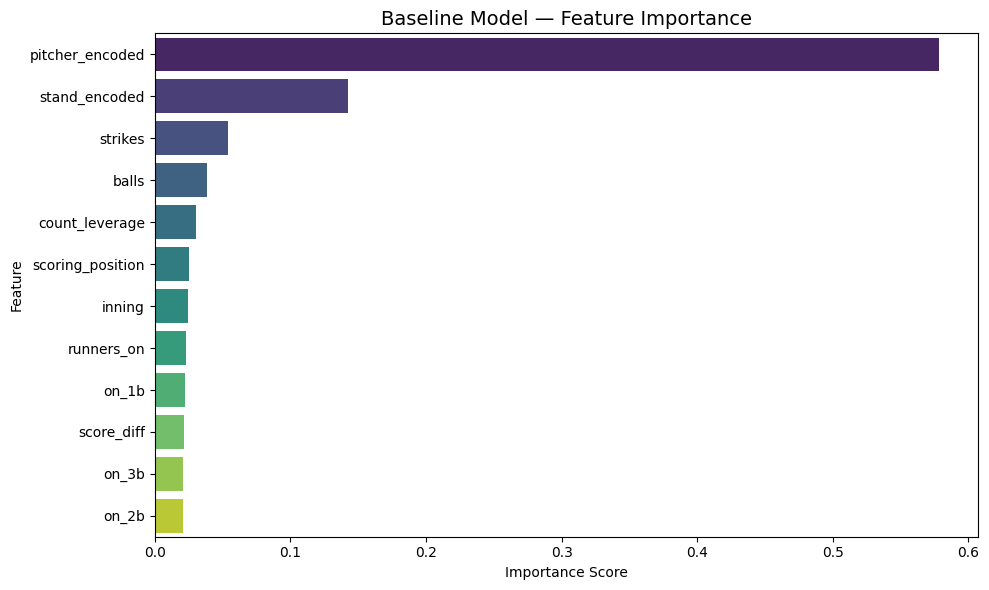

In [54]:
# Feature importance from XGBoost
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importance ===")
print(importance_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df, 
    x='importance', 
    y='feature',
    hue='feature',
    legend=False,
    palette='viridis',
    ax=ax
)
ax.set_title("Baseline Model — Feature Importance", fontsize=14)
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

## A Note on Model Accuracy

Pitch selection involves intentional deception and randomness by design.
A pitcher who is perfectly predictable would be ineffective at the major
league level. An accuracy meaningfully above random chance (~11% for 9 
classes) demonstrates the model has learned real patterns. The goal of 
this model is not perfect prediction but rather establishing a statistical
baseline from which individual pitcher deviations can be measured.

# Visualization of Model Performance

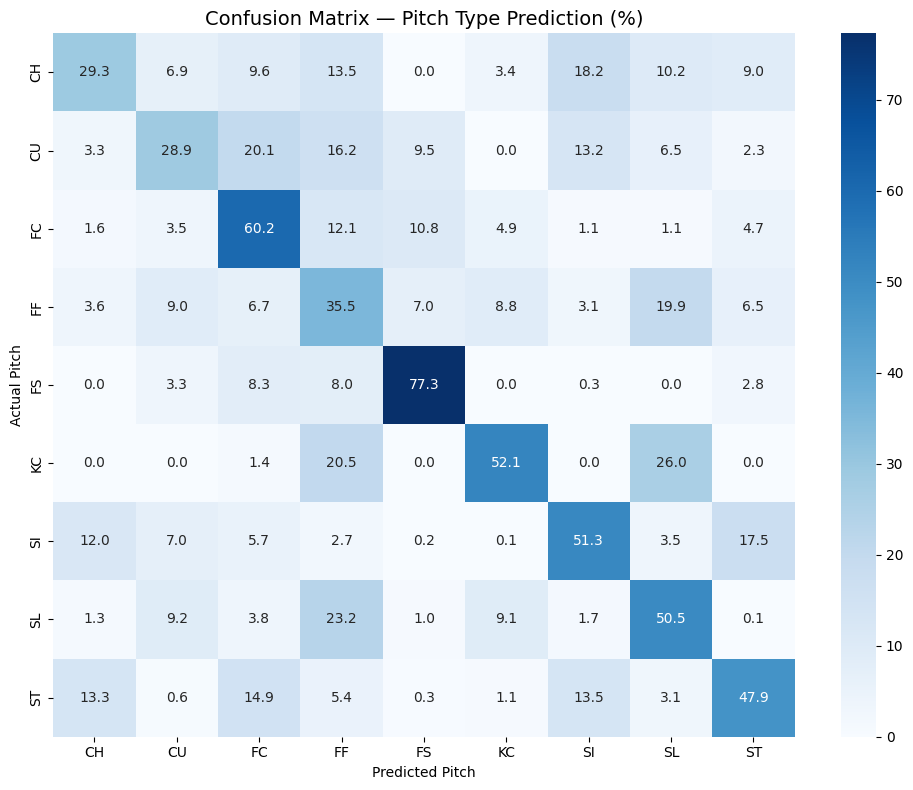

In [55]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct,
            annot=True,
            fmt='.1f',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues',
            ax=ax)
ax.set_title("Confusion Matrix — Pitch Type Prediction (%)", fontsize=14)
ax.set_ylabel("Actual Pitch")
ax.set_xlabel("Predicted Pitch")
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Add SHAP Explainability

In [ ]:
import shap

print("Generating SHAP values — this may take a moment...")
explainer = shap.TreeExplainer(model)
shap_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Global feature importance across all pitch types
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_cols,
    class_names=le.classes_,
    show=False
)
plt.title("SHAP Summary — What Drives Pitch Selection?")
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

Generating SHAP values — this may take a moment...


<Figure size 1000x600 with 0 Axes>

# Saves Model

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/baseline_pitch_model.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
joblib.dump(pitcher_encoder, '../models/pitcher_encoder.pkl')

print("=== Models Saved ===")
print("baseline_pitch_model.pkl")
print("label_encoder.pkl")
print("pitcher_encoder.pkl")

# Calculate Summary Statistics

In [ ]:
from datetime import datetime
print(f"Model last run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# Summary statistics to reference for markdown summary
print("=== PHASE 2 SUMMARY STATISTICS ===")
print(f"\nDataset:")
print(f"  Total pitches: {len(data)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")
print(f"  Pitch types modeled: {sorted(le.classes_)}")

print(f"\nModel Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

print(f"\nStrongest Classes (by f1-score):")
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, 
                                target_names=le.classes_, 
                                output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() 
             if k in le.classes_}
for pitch, f1 in sorted(f1_scores.items(), 
                         key=lambda x: x[1], reverse=True):
    print(f"  {pitch}: {f1:.3f}")

print(f"\nFeature Importance (top 3):")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f} "
          f"({row['importance']*100:.1f}%)")

## Phase 2 Results Summary

### Dataset
- **Total pitches modeled:** 72,098 across 15 pitchers (2023-2024)
- **Training samples:** 57,678
- **Testing samples:** 14,420
- **Pitch types:** CH, CU, FC, FF, FS, KC, SI, SL, ST

### Model Performance
- **Accuracy:** 0.426
- **Balanced Accuracy:** 0.481
- **Strongest classes:** SI (0.524), FC (0.510), SL (0.467)
- **Most challenging classes:** KC (0.253), CU (0.294)

### Feature Importance Findings
- **Pitcher identity** is the dominant predictor at 57.8%, confirming
  that individual arsenal and tendencies drive pitch selection more
  than any situational factor
- **Batter handedness** is the strongest situational feature at 14.2%,
  consistent with conventional pitching wisdom
- **Strike count** (5.4%) and **ball count** (3.8%) are the strongest
  pure count features, reflecting how two-strike and three-ball counts
  shift pitch selection

### Interpretation
This baseline model establishes the statistical foundation for deviation
analysis in Phase 3. The dominance of pitcher identity as a feature
raises an important design question for deviation scoring — deviations
can be measured against universal league norms (removing pitcher identity)
or against each pitcher's own tendencies (keeping pitcher identity).
Phase 3 will explore both approaches.

### Model Limitations
- Rare pitch types (KC, ST) remain difficult to predict precisely
  due to limited sample sizes
- Intentional deception is inherent to pitching, creating a natural
  ceiling on predictability
- A balanced accuracy of 0.481 against a random baseline of ~0.111
  for 9 classes represents meaningful signal